In [5]:
import pandas as pd 

df_new = pd.read_parquet(
    "s3://clean/scoring/month=202601/scoring_data_20260307_045508.parquet",
    engine="pyarrow",
    storage_options={
        "key": "minio",
        "secret": "minio123",
        "client_kwargs": {
            "endpoint_url": "http://minio:9990"
        }
    },
)
# df_new = df_new[df_new["recommendation"] == 1]
# df_new = df_new.rename(columns=lambda c: c if c == "user_id" else f"{c}_new")

In [6]:
df_old = pd.read_parquet(
    "s3://clean/scoring/month=202601/scoring_data_20260227_180303.parquet",
    engine="pyarrow",
    storage_options={
        "key": "minio",
        "secret": "minio123",
        "client_kwargs": {
            "endpoint_url": "http://minio:9990"
        }
    },
)

# df_old = df_old[df_old["recommendation"] == 1]
# df_old = df_old.rename(columns=lambda c: c if c == "user_id" else f"{c}_old")

In [7]:
pd.set_option("display.max_columns", None)

In [8]:
df_compare = df_old.merge(df_new, on="user_id", how="outer")

cols = ["user_id"] + sorted([c for c in df_compare.columns if c != "user_id"])
df_compare = df_compare[cols]
df_compare

,user_id,age_x,age_y,avg_success_order_count_per_month_x,avg_success_order_count_per_month_y,avg_success_order_value_per_month_x,avg_success_order_value_per_month_y,behavior_score_x,behavior_score_y,date_x,date_y,gvm_score_x,gvm_score_y,model_version_x,model_version_y,month_x,month_y,phone_x,phone_y,recommendation_x,recommendation_y,revenue_decline_last_3_quarters_x,revenue_decline_last_3_quarters_y,revenue_decline_last_4_months_x,revenue_decline_last_4_months_y,rule_score_x,rule_score_y,sales_region_x,sales_region_y,score_x,score_y,total_success_order_value_per_month_x,total_success_order_value_per_month_y,trend_score_x,trend_score_y,usage_duration_months_x,usage_duration_months_y
0,1,0,0,0.0,0.0,0.0,0.0,0.201010,0.201010,2026-02-27,2026-03-07,0.01000001,0.01000001,v1.0.0,v1.0.0,202601,202601,091,091,0,0,1,1,0.0,0.0,0,0,1,1,0,0,0.0,0.0,0.00,0.00,1,1
1,10000004,0,0,0.0,0.0,0.0,0.0,0.141010,0.141010,2026-02-27,2026-03-07,0.01000001,0.01000001,v1.0.0,v1.0.0,202601,202601,0910000004,0910000004,0,0,1,1,0.0,0.0,0,0,1,1,0,0,0.0,0.0,0.00,0.00,1,1
2,10000066,0,0,0.0,0.0,0.0,0.0,0.141010,0.141010,2026-02-27,2026-03-07,0.01000001,0.01000001,v1.0.0,v1.0.0,202601,202601,0910000066,0910000066,0,0,1,1,0.0,0.0,1,0,1,1,0,0,0.0,0.0,0.00,0.00,1,1
3,10000085,0,0,0.0,0.0,0.0,0.0,0.141170,0.141170,2026-02-27,2026-03-07,0.16000007,0.15000007,v1.0.0,v1.0.0,202601,202601,0910000085,0910000085,0,0,0,0,1.0,1.0,0,0,0,0,0,0,0.0,0.0,0.22,0.22,1,1
4,10000108,1,1,0.0,0.0,0.0,0.0,0.141070,0.141070,2026-02-27,2026-03-07,0.06000001,0.07000001,v1.0.0,v1.0.0,202601,202601,0910000108,0910000108,0,0,1,1,1.0,1.0,0,0,1,1,0,0,0.0,0.0,0.11,0.11,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716227,9999764,0,0,1.0,1.0,0.0,0.0,0.141161,0.141161,2026-02-27,2026-03-07,0.15000003,0.16000003,v1.0.0,v1.0.0,202601,202601,099999764,099999764,0,0,1,1,1.0,1.0,1,0,1,1,0,0,0.0,0.0,0.02,0.02,1,1
716228,9999797,1,1,0.0,0.0,0.0,0.0,0.141010,0.141010,2026-02-27,2026-03-07,0.01000001,0.01000001,v1.0.0,v1.0.0,202601,202601,099999797,099999797,0,0,1,1,0.0,0.0,1,1,0,0,0,0,0.0,0.0,0.00,0.00,1,1
716229,99998,1,1,0.0,0.0,0.0,0.0,0.201080,0.201080,2026-02-27,2026-03-07,0.04000001,0.06000001,v1.0.0,v1.0.0,202601,202601,0999998,0999998,0,0,0,0,1.0,1.0,1,0,0,0,0,0,0.0,0.0,0.21,0.21,1,1
716230,9999818,0,0,0.0,0.0,0.0,0.0,0.141070,0.141070,2026-02-27,2026-03-07,0.02000001,0.06000001,v1.0.0,v1.0.0,202601,202601,099999818,099999818,0,0,1,1,1.0,1.0,1,0,1,1,0,0,0.0,0.0,0.01,0.01,1,1


In [6]:
df_compare[df_compare.recommendation_new.isnull()]

,user_id,age_new,age_old,avg_success_order_count_per_month_new,avg_success_order_count_per_month_old,avg_success_order_value_per_month_new,avg_success_order_value_per_month_old,behavior_score_new,behavior_score_old,date_new,date_old,gvm_score_new,gvm_score_old,model_version_new,model_version_old,month_new,month_old,phone_new,phone_old,recommendation_new,recommendation_old,revenue_decline_last_3_quarters_new,revenue_decline_last_3_quarters_old,revenue_decline_last_4_months_new,revenue_decline_last_4_months_old,rule_score_new,rule_score_old,sales_region_new,sales_region_old,score_new,score_old,total_success_order_value_per_month_new,total_success_order_value_per_month_old,trend_score_new,trend_score_old,usage_duration_months_new,usage_duration_months_old
4596,16700475,NaN,0,NaN,1.0,NaN,1.0,NaN,0.021201,NaN,2026-02-27,NaN,0.20110085,NaN,v1.0.0,NaN,202601,NaN,0916700475,NaN,1,NaN,1,NaN,1.0,NaN,0,NaN,1,NaN,0,NaN,1.0,NaN,0.01,NaN,1
4603,16854194,NaN,0,NaN,1.0,NaN,1.0,NaN,0.010201,NaN,2026-02-27,NaN,0.20110204,NaN,v1.0.0,NaN,202601,NaN,0916854194,NaN,1,NaN,1,NaN,1.0,NaN,1,NaN,1,NaN,0,NaN,1.0,NaN,0.01,NaN,0
4604,16883677,NaN,0,NaN,1.0,NaN,1.0,NaN,0.010201,NaN,2026-02-27,NaN,0.20110556,NaN,v1.0.0,NaN,202601,NaN,0916883677,NaN,1,NaN,1,NaN,1.0,NaN,0,NaN,1,NaN,0,NaN,1.0,NaN,0.01,NaN,0
5219,6517171,NaN,0,NaN,1.0,NaN,1.0,NaN,0.171201,NaN,2026-02-27,NaN,0.20110245,NaN,v1.0.0,NaN,202601,NaN,096517171,NaN,1,NaN,1,NaN,1.0,NaN,0,NaN,1,NaN,0,NaN,1.0,NaN,0.01,NaN,1


In [33]:
df_new[df_new.user_id == "6517171"]

,user_id,age,usage_duration_months,sales_region,avg_success_order_value_per_month,total_success_order_value_per_month,avg_success_order_count_per_month,revenue_decline_last_3_quarters,revenue_decline_last_4_months,behavior_score,gvm_score,trend_score,recommendation,score,rule_score,phone,date,model_version,month
579630,6517171,0,1,1,0.0,0.0,1.0,1,1.0,0.171201,0.20000245,0.01,0,0,1,096517171,2026-03-07,v1.0.0,202601


In [128]:
df_old[df_old.user_id == "12765095"]

,user_id,age,usage_duration_months,sales_region,avg_success_order_value_per_month,total_success_order_value_per_month,avg_success_order_count_per_month,revenue_decline_last_3_quarters,revenue_decline_last_4_months,behavior_score,gvm_score,trend_score,recommendation,score,rule_score,phone,date,model_version,month


In [24]:
scoring_month = "202601"
df = extract_scoring_data(scoring_month)

Xét dữ liệu từ tháng 202501 đến tháng 202512


In [129]:
df[df.cus_id == "12765095"]

,cus_id,month,tong_tien


### Phan tich rule 3 4 

In [84]:
def transform_avg_success_order_value_per_month(df: pd.DataFrame, column_name: str, config=None) -> pd.DataFrame:
    """
    Xử lý cột tong_tien
    -> trả về bảng avg_success_order_value_per_month với 3 cột: cus_id, month (đếm số tháng hđ),tong_tien (Trung bình) và avg_success_order_value_per_month
    """
    months_window = 6
    min_avg_success_order = 10000000
    # đầu tiên cần lấy ra tháng cao nhất
    temp_df = df.copy()
    
    temp_df["month"] = pd.to_datetime(temp_df["month"], format="%Y%m")
    temp_df["month"] = temp_df["month"].dt.to_period("M")
    max_month = temp_df["month"].max()
    
    # Chỉ trích xuất X tháng gần nhất
    min_month = max_month - months_window + 1 # phải cộng 1 vì như này: ví dụ tháng 
                                              # 12 thì phải trích xuất 6 tháng gần nhất từ tháng 7 đến tháng 12
    
    print("Tính toán avg_success_order_value_per_month xét từ tháng", min_month, "đến tháng", max_month)

    # tinh tong tien o tat ca chi nhanh va thang hoat dong
    df_avg_success_order_value_per_month = temp_df[temp_df["month"].between(min_month, max_month)].groupby("cus_id").agg({column_name: "sum", "month": "nunique"}).reset_index()
    
    # tinh trung binh tien theo thang
    df_avg_success_order_value_per_month["avg_success_order_value_per_month"] = df_avg_success_order_value_per_month[column_name] / df_avg_success_order_value_per_month["month"]
    
    # # Hơn nữa nếu số tháng ghi nhận được từ khách hàng < 6 tháng thì trả về 0
    # df_avg_success_order_value_per_month["avg_success_order_value_per_month"] = np.where((df_avg_success_order_value_per_month["avg_success_order_value_per_month"] >= min_avg_success_order) & (df_avg_success_order_value_per_month["month"] == months_window), 1, 0)

    # df_avg_success_order_value_per_month["score_2"] = \
    #                 binning_data(df_avg_success_order_value_per_month,column_name,20) + df_avg_success_order_value_per_month["avg_success_order_value_per_month"].astype("str")
    
    # return df_avg_success_order_value_per_month[["cus_id", "avg_success_order_value_per_month", "score_2"]]
    return df_avg_success_order_value_per_month[["cus_id", column_name, "avg_success_order_value_per_month", "month"]]

In [85]:
# def transform_avg_success_order_value_per_month(df: pd.DataFrame, column_name: str, config=None) -> pd.DataFrame:
#     """
#     Xử lý cột tong_tien
#     -> trả về bảng avg_success_order_value_per_month với 3 cột: cus_id, month (đếm số tháng hđ),tong_tien (Trung bình) và avg_success_order_value_per_month
#     """
#     months_window = 6
#     min_avg_success_order = 10000000
#     # đầu tiên cần lấy ra tháng cao nhất
#     temp_df = df.copy()
    
#     temp_df["month"] = pd.to_datetime(temp_df["month"], format="%Y%m")
#     temp_df["month"] = temp_df["month"].dt.to_period("M")
#     max_month = temp_df["month"].max()
    
#     # Chỉ trích xuất X tháng gần nhất
#     min_month = max_month - months_window + 1 # phải cộng 1 vì như này: ví dụ tháng 
#                                               # 12 thì phải trích xuất 6 tháng gần nhất từ tháng 7 đến tháng 12
    
#     print("Tính toán avg_success_order_value_per_month xét từ tháng", min_month, "đến tháng", max_month)
    
#     df_avg_success_order_value_per_month = temp_df[temp_df["month"].between(min_month, max_month)].groupby("cus_id").agg({column_name: "mean", "month": "count"}).reset_index()
#     df_avg_success_order_value_per_month["avg_success_order_value_per_month"] = df_avg_success_order_value_per_month[column_name]
    
#     # # Hơn nữa nếu số tháng ghi nhận được từ khách hàng < 6 tháng thì trả về 0
#     # df_avg_success_order_value_per_month["avg_success_order_value_per_month"] = np.where((df_avg_success_order_value_per_month[column_name] >= min_avg_success_order) & (df_avg_success_order_value_per_month["month"] == months_window), 1, 0)

#     # df_avg_success_order_value_per_month["score_2"] = \
#     #                 binning_data(df_avg_success_order_value_per_month,column_name,20) + df_avg_success_order_value_per_month["avg_success_order_value_per_month"].astype("str")
    
#     # return df_avg_success_order_value_per_month[["cus_id", "avg_success_order_value_per_month", "score_2"]]
#     return df_avg_success_order_value_per_month[["cus_id", column_name, "avg_success_order_value_per_month", "month"]]

In [86]:
import sys
from src.scripts.scoring.extract.extract_data import extract_scoring_data
from src.scripts.scoring.transform.transform_data import main_transform_data
from src.scripts.scoring.load.to_postgres import load_data_to_postgres
from src.scripts.scoring.load.to_minio import load_data_to_minio
from src.scripts.utils import common as utils
import numpy as np
    
def main_scoring(scoring_month):
    # Extract data
    df = extract_scoring_data(scoring_month)
    df = transform_avg_success_order_value_per_month(df, "tong_tien")
    return df

df = main_scoring("202601")
df["pass_value"] = df["avg_success_order_value_per_month"] >= 10000000
df["pass_window"] = df["month"] == 6

Xét dữ liệu từ tháng 202501 đến tháng 202512
Tính toán avg_success_order_value_per_month xét từ tháng 2025-07 đến tháng 2025-12


In [87]:
df[["pass_value", "pass_window"]].value_counts()

pass_value  pass_window
False       False          388812
            True           105299
True        True            10539
            False            7473
Name: count, dtype: int64

In [88]:
df["pass_value"].mean(), df["pass_window"].mean()

(np.float64(0.03517123815958276), np.float64(0.22619175471517586))

cu: 
pass_value  pass_window
False       False          411966
            True            83411
True        False            8516
            True             8230

(np.float64(0.03269917578394253), np.float64(0.1789433397836067))


===================================
moi:
pass_value  pass_window
False       False          388812
            True           105299
True        True            10539
            False            7473

(np.float64(0.03517123815958276), np.float64(0.22619175471517586))


### phan tich percentile

In [125]:
df = extract_scoring_data(scoring_month)
df["month"] = df["month"].astype(str)
df = df.groupby(["cus_id", "month"])["tong_tien"].sum().reset_index()
df

Xét dữ liệu từ tháng 202501 đến tháng 202512


,cus_id,month,tong_tien
0,1,202505,66000.0
1,10000004,202505,33000.0
2,10000004,202506,522997.0
3,10000066,202505,16500.0
4,10000085,202501,540807.0
...,...,...,...
3053448,9999875,202508,2523804.0
3053449,9999875,202509,1031569.0
3053450,9999875,202510,383757.0
3053451,9999875,202511,801120.0


In [126]:
df_month = df[df.month == "202511"]

In [127]:
df_month["bin"] = pd.qcut(df_month["tong_tien"], 20, duplicates="drop")

stat = (
    df_month.groupby("bin")
    .agg(
        total_users=("cus_id", "count"),
        avg_value_of_bin=("tong_tien", "mean")
    )
    .reset_index()
)

stat["pct_total"] = stat["total_users"] / stat["total_users"].sum()
stat["avg_value_of_bin"] = stat["avg_value_of_bin"].astype(int)
stat

/tmp/ipykernel_1320751/2086484826.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_month["bin"] = pd.qcut(df_month["tong_tien"], 20, duplicates="drop")
/tmp/ipykernel_1320751/2086484826.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_month.groupby("bin")


,bin,total_users,avg_value_of_bin,pct_total
0,"(0.999, 17600.0]",13305,13269,0.051897
1,"(17600.0, 27001.0]",12350,21916,0.048172
2,"(27001.0, 33000.0]",13556,30274,0.052876
3,"(33000.0, 41501.0]",12112,37047,0.047243
4,"(41501.0, 55998.5]",12771,48410,0.049814
5,"(55998.5, 72000.0]",12955,63538,0.050531
6,"(72000.0, 94324.9]",12682,82778,0.049467
7,"(94324.9, 124700.0]",12822,108736,0.050013
8,"(124700.0, 164003.3]",12816,143099,0.049989
9,"(164003.3, 219000.0]",12823,190133,0.050017


In [ ]:
df_new = pd.read_parquet(
    "s3://clean/scoring/month=202601/scoring_data_20260307_045508.parquet",
    engine="pyarrow",
    storage_options={
        "key": "minio",
        "secret": "minio123",
        "client_kwargs": {
            "endpoint_url": "http://minio:9990"
        }
    },
)

### danh gia data 

In [6]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.0f}'.format)

In [7]:
df = pd.read_parquet(
    "../data/data_hitech_month/",
    filters=[("partition", ">=", 202602)],
    engine="pyarrow"
)

df

,cus_id,p5_tongtien,p10_tongtien,p25_tongtien,p50_tongtien,p75_tongtien,p90_tongtien,p95_tongtien,tongdon_cao,tongdon_thap,sanluong_phat_yeucau,khachhang_nhan,khachhang_nhieudon,khachhang_moi,khachhang_thangtruoc,khachhang_quaylai,khachhang_roibo,partition
0,17545158,5000,16000,18000,18000,18000,18000,18000,1320,176,1398,1470,16,1442,2975,28,2947,202602
1,1567895,11000,11000,12000,33000,55599,128501,285501,5,5,42,32,0,29,61,2,59,202602
2,6730956,5000,11000,13200,28000,32118,35001,36416,39,35,152,153,9,126,351,21,330,202602
3,16693176,15770,15770,29954,41204,49612,58297,69007,253,514,2746,2427,349,950,3925,1327,2598,202602
4,16764849,12000,16500,22000,22000,24000,24206,27500,31,40,329,304,10,267,608,28,580,202602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
570916,16758097,37600,37600,37600,37600,37600,37600,37600,1,1,1,1,0,NaN,NaN,NaN,NaN,202602
570917,17836335,19999,19999,19999,19999,19999,19999,19999,1,1,1,1,0,1,NaN,NaN,NaN,202602
570918,13868547,25000,25000,25000,25000,25000,25000,25000,1,1,2,1,0,1,5,0,5,202602
570919,17645068,24999,24999,24999,24999,24999,24999,24999,1,1,1,1,0,1,1,0,1,202602


In [3]:
df['loai_khachhang'].unique()

array(['Hộ kinh doanh cá thể', 'Cá nhân', None,
       'Doanh nghiệp vừa và nhỏ (SME)', 'Doanh nghiệp lớn',
       'Khách hàng chính phủ', 'Sàn', 'Cổng vận chuyển'], dtype=object)

In [4]:
df_groupby_month = df.groupby(["cus_id"]).agg(
    tong_tien=("tong_tien", "sum"),
    tong_don=("tong_don", "sum"),
    don_ptc=("don_ptc", "sum"),
    don_hoan=("don_hoan", "sum"),
    don_fail=("don_fail", "sum"),
    loai_khachhang=("loai_khachhang", "min")
).reset_index()

In [30]:
df_groupby_month['loai_khachhang'].value_counts(1) * 100

loai_khachhang
Cá nhân                         73
Hộ kinh doanh cá thể            20
Doanh nghiệp vừa và nhỏ (SME)    7
Doanh nghiệp lớn                 1
Khách hàng chính phủ             0
Cổng vận chuyển                  0
Sàn                              0
Name: proportion, dtype: float64

In [5]:
df_groupby_month.cus_id.nunique()

836021

In [6]:
df_groupby_month.groupby("loai_khachhang").agg(
    # ===== SUM (quy mô) =====
    tong_tien_mean=("tong_tien", "mean"),
    tong_don_mean=("tong_don", "mean"),
    don_ptc_mean=("don_ptc", "mean"),
    don_hoan_mean=("don_hoan", "mean"),
    don_fail_mean=("don_fail", "mean"),

    # ===== MIN / MAX =====
    tong_tien_min=("tong_tien", "min"),
    tong_tien_max=("tong_tien", "max"),

    tong_don_max=("tong_don", "max"),

    # ===== PERCENTILE =====
    tong_tien_p25=("tong_tien", lambda x: x.quantile(0.25)),
    tong_tien_p50=("tong_tien", lambda x: x.quantile(0.50)),
    tong_tien_p75=("tong_tien", lambda x: x.quantile(0.75)),

    tong_don_p25=("tong_don", lambda x: x.quantile(0.25)),
    tong_don_p50=("tong_don", lambda x: x.quantile(0.50)),
    tong_don_p75=("tong_don", lambda x: x.quantile(0.75)),

    # ===== SIZE =====
    so_merchant=("cus_id", "nunique"),
)

,tong_tien_mean,tong_don_mean,don_ptc_mean,don_hoan_mean,don_fail_mean,tong_tien_min,tong_tien_max,tong_don_max,tong_tien_p25,tong_tien_p50,tong_tien_p75,tong_don_p25,tong_don_p50,tong_don_p75,so_merchant
loai_khachhang,,,,,,,,,,,,,,,
Cá nhân,540904,15,9,1,9,-2751,11756067812,51533,36100,76100,191504,1,2,5,487762
Cổng vận chuyển,35096564,1261,979,125,1124,13000,979303924,61703,109003,712708,7563389,2,12,92,83
Doanh nghiệp lớn,2586819,52,35,2,21,0,414832320,10646,86494,291097,889404,2,9,28,3683
Doanh nghiệp vừa và nhỏ (SME),3349089,53,39,1,18,0,22482629654,66237,126999,345144,1007277,4,12,33,45850
Hộ kinh doanh cá thể,5028395,158,125,8,93,0,38296958979,1302399,400302,1062138,3216181,9,27,79,130517
Khách hàng chính phủ,5754076,228,173,6,73,11000,876847638,32251,168300,471898,1560765,6,20,56,314
Sàn,927468607,38923,34559,1905,22019,16500,65669451341,2761060,50751,189692,829972,2,5,16,71


In [7]:
df_groupby_month[df_groupby_month.tong_tien == 11756067812]

,cus_id,tong_tien,tong_don,don_ptc,don_hoan,don_fail,loai_khachhang
276378,1456649,11756067812,3,0,0,0,Cá nhân


In [47]:
df[df.cus_id == '1456649']

,cus_id,ten_phuongxa_hoatdong_chinh,ten_quanhuyen_hoatdong_chinh,ma_tinh_hoatdong_chinh,tongdon_diaban_chinh,tong_tien,min_tongtien,max_tongtien,tong_don,avg_tongtien,trong_luong,min_trongluong,max_trongluong,thu_ho,don_ptc,don_hoan,sanluong_phat_yeucau,don_fail,khachhang_nhan,khachhang_nhieudon,khachhang_moi_flag_daily,sanluong_cptn,sanluong_exp,sanluong_fwd,sanluong_kho,sanluong_vt,sanluong_khac,lydo_hoan,so_donhoan_nhieunhat,lydo_khieunai,so_khieunai_nhieunhat,ngay_hoptac,ngay_sinh,ten_dangky,nganh_hang,loai_khachhang,partition
3423611,1456649,None,None,HNI,1,5370443967,5370443967,5370443967,1,5370443967,50,50,50,NaN,NaN,NaN,NaN,NaN,1,0,1,1,0,0,0,0,0,None,NaN,NaN,NaN,29/06/2018,None,Cao Hạ Anh,Khác,Cá nhân,20251225
4142608,1456649,None,None,HNI,2,6385623845,2014324357,4371299488,2,3192811922,100,50,50,NaN,NaN,NaN,NaN,NaN,1,1,0,2,0,0,0,0,0,None,NaN,NaN,NaN,29/06/2018,None,Cao Hạ Anh,Khác,Cá nhân,20251231


In [21]:
df_gp_filter = df_groupby_month[(df_groupby_month.tong_tien >= 500000) & (df_groupby_month.tong_tien <= 5000000)]


df_gp_filter.groupby("loai_khachhang").agg(
    # ===== SUM (quy mô) =====
    tong_tien_mean=("tong_tien", "mean"),
    tong_don_mean=("tong_don", "mean"),
    don_ptc_mean=("don_ptc", "mean"),
    don_hoan_mean=("don_hoan", "mean"),
    don_fail_mean=("don_fail", "mean"),

    # ===== MIN / MAX =====
    tong_tien_min=("tong_tien", "min"),
    tong_tien_max=("tong_tien", "max"),

    tong_don_max=("tong_don", "max"),

    # ===== PERCENTILE =====
    tong_tien_p25=("tong_tien", lambda x: x.quantile(0.25)),
    tong_tien_p50=("tong_tien", lambda x: x.quantile(0.50)),
    tong_tien_p75=("tong_tien", lambda x: x.quantile(0.75)),

    tong_don_p25=("tong_don", lambda x: x.quantile(0.25)),
    tong_don_p50=("tong_don", lambda x: x.quantile(0.50)),
    tong_don_p75=("tong_don", lambda x: x.quantile(0.75)),

    # ===== SIZE =====
    so_merchant=("cus_id", "nunique"),
)

,tong_tien_mean,tong_don_mean,don_ptc_mean,don_hoan_mean,don_fail_mean,tong_tien_min,tong_tien_max,tong_don_max,tong_tien_p25,tong_tien_p50,tong_tien_p75,tong_don_p25,tong_don_p50,tong_don_p75,so_merchant
loai_khachhang,,,,,,,,,,,,,,,
Cá nhân,1313939,32,17,1,10,500000,4999438,453,640040,904392,1589342,9,18,37,40252
Cổng vận chuyển,2320213,46,25,1,10,522551,4532197,125,867890,2516084,3192259,11,44,62,18
Doanh nghiệp lớn,1525189,48,30,1,7,501691,4977183,353,720976,1124892,2072890,20,35,61,1091
Doanh nghiệp vừa và nhỏ (SME),1498782,48,30,0,6,500001,4993424,518,714016,1101389,1930966,21,36,60,15402
Hộ kinh doanh cá thể,1753165,52,33,1,14,500000,4999849,522,823976,1364956,2404931,19,35,67,68118
Khách hàng chính phủ,1561043,65,36,1,13,506303,4949381,401,767905,1189499,1954479,28,47,81,120
Sàn,1409485,26,11,0,5,571397,3132736,68,891494,1169617,1551005,19,21,39,13


Khách hàng: Hộ kinh doanh cá thể


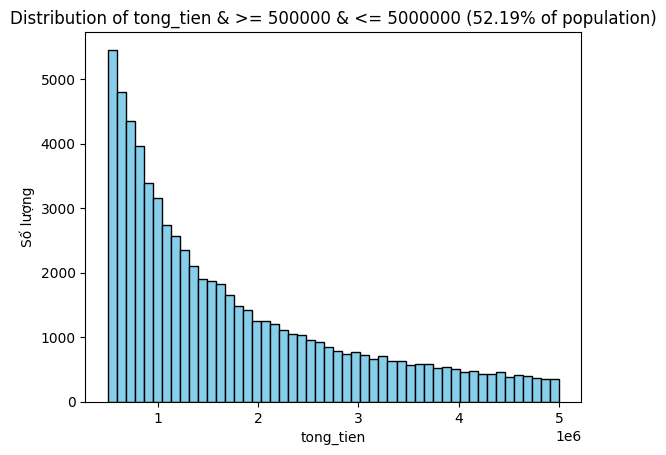

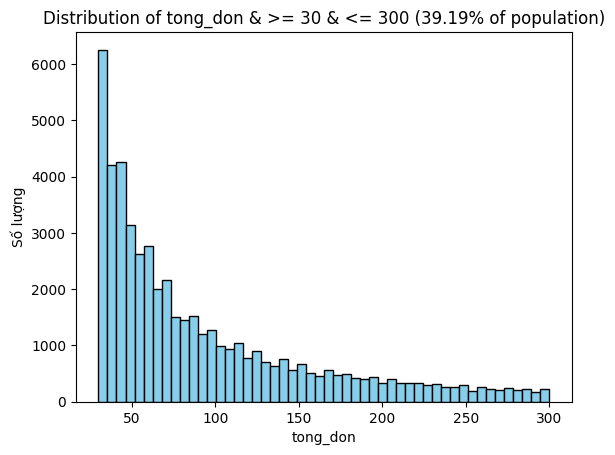

tong_tien: Percent: 52.19% | Pool size: 68118 | Lead size: 340.59 | Disbursement: 8,514,750,000
tong_don: Percent: 39.19% | Pool size: 51156 | Lead size: 255.78 | Disbursement: 6,394,500,000


Khách hàng: Doanh nghiệp vừa và nhỏ (SME)


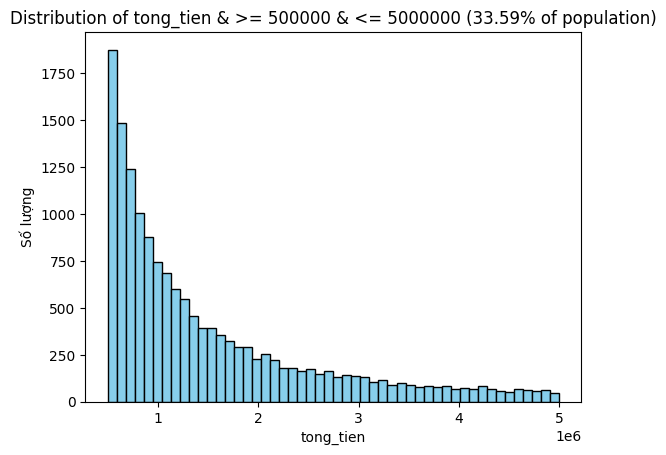

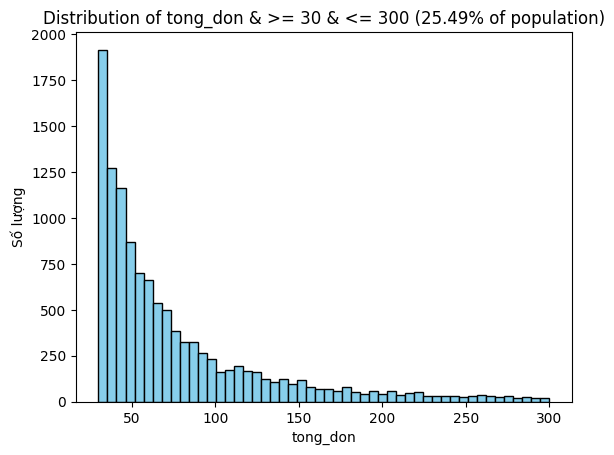

tong_tien: Percent: 33.59% | Pool size: 15402 | Lead size: 77.01 | Disbursement: 1,925,250,000
tong_don: Percent: 25.49% | Pool size: 11686 | Lead size: 58.43 | Disbursement: 1,460,750,000




In [46]:
import matplotlib.pyplot as plt

def plot_filtered_hist(df, column, lower_threshold=None, upper_threshold=None, bins=50):
    # Tổng số mẫu
    total_count = len(df)
    
    # Lọc dữ liệu theo ngưỡng
    df_filtered = df.copy()
    if lower_threshold is not None:
        df_filtered = df_filtered[df_filtered[column] >= lower_threshold]
    if upper_threshold is not None:
        df_filtered = df_filtered[df_filtered[column] <= upper_threshold]
    
    # Số mẫu thỏa điều kiện
    filtered_count = len(df_filtered)
    
    # Tính phần trăm
    percent = (filtered_count / total_count) * 100
    
    # Vẽ histogram
    plt.hist(df_filtered[column], bins=bins, color='skyblue', edgecolor='black')
    plt.xlabel(column)
    plt.ylabel("Số lượng")
    
    # Tạo tiêu đề với phần trăm
    title_parts = [f"{column}"]
    if lower_threshold is not None:
        title_parts.append(f">= {lower_threshold}")
    if upper_threshold is not None:
        title_parts.append(f"<= {upper_threshold}")
    title_str = " & ".join(title_parts)
    plt.title(f"Distribution of {title_str} ({percent:.2f}% of population)")
    
    plt.show()

    return percent

# Ví dụ sử dụng
for cus_type in ['Hộ kinh doanh cá thể', 'Doanh nghiệp vừa và nhỏ (SME)']:
    # 'Cá nhân', 
    print(f"Khách hàng: {cus_type}")
    _df_filter = df_groupby_month[df_groupby_month.loai_khachhang == cus_type]
    
    results = {}
    # Xử lý cả tong_tien và tong_don
    for col, lower, upper in [('tong_tien', 500_000, 5_000_000), ('tong_don', 30, 300)]:
        percent = plot_filtered_hist(_df_filter, col, lower_threshold=lower, upper_threshold=upper)
        pool_size = _df_filter.shape[0] * (percent / 100)
        lead_size = pool_size * 0.5 * 0.01
        disbursement = lead_size * 25_000_000
        
        results[col] = {
            "percent": percent,
            "pool_size": pool_size,
            "lead_size": lead_size,
            "disbursement": disbursement
        }
    
    # In kết quả
    for col, vals in results.items():
        print(f"{col}: Percent: {vals['percent']:.2f}% | Pool size: {vals['pool_size']:.0f} | "
              f"Lead size: {vals['lead_size']:.2f} | Disbursement: {vals['disbursement']:,.0f}")
    print("\n")

### khai thac trong pool ca nhan: tim sme/hkd

In [49]:
_df_filter = df_groupby_month[df_groupby_month.loai_khachhang == 'Cá nhân']
_df_filter

,cus_id,tong_tien,tong_don,don_ptc,don_hoan,don_fail,loai_khachhang
0,1,38501,1,0,0,0,Cá nhân
1,10000004,19999,1,0,0,0,Cá nhân
2,10000104,30000,1,0,0,0,Cá nhân
3,10000113,74002,3,0,0,0,Cá nhân
4,10000147,540907,14,3,0,0,Cá nhân
...,...,...,...,...,...,...,...
836015,99998,58000,2,0,0,0,Cá nhân
836016,9999818,148559,8,1,0,0,Cá nhân
836017,9999842,42500,1,0,0,0,Cá nhân
836018,9999846,25000,1,0,0,0,Cá nhân


In [50]:
_df_filter.tong_don.describe()

count   487762
mean        15
std        248
min          1
25%          1
50%          2
75%          5
max      51533
Name: tong_don, dtype: float64

In [54]:
_df_filter.tong_don.describe(percentiles=[i/100 for i in range(5, 100, 5)])

count   487762
mean        15
std        248
min          1
5%           1
10%          1
15%          1
20%          1
25%          1
30%          1
35%          1
40%          1
45%          2
50%          2
55%          2
60%          3
65%          3
70%          4
75%          5
80%          6
85%          8
90%         11
95%         22
max      51533
Name: tong_don, dtype: float64

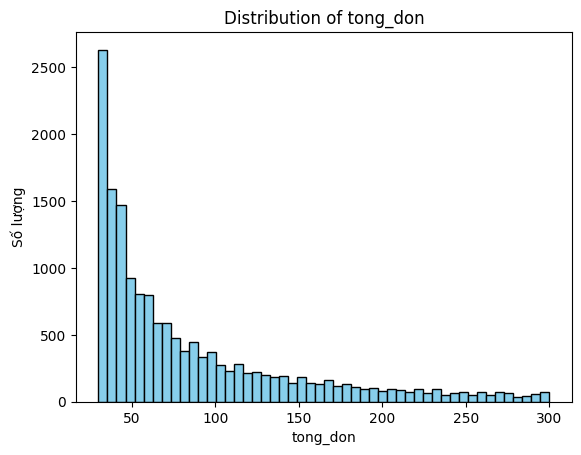

3.232724156453352

In [65]:
df_1 = _df_filter[(_df_filter.tong_don >= 30) & (_df_filter.tong_don <= 300)]

import matplotlib.pyplot as plt

plt.hist(df_1['tong_don'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('tong_don')
plt.ylabel('Số lượng')
plt.title('Distribution of tong_don')
plt.show()

df_1.shape[0] / _df_filter.shape[0] * 100

In [69]:
df_1.shape[0] * 0.5 * 0.01

78.84

In [71]:
(80 * 30000000) + (350 * 35000000)

14650000000

In [ ]:
import pandas as pd

df = pd.read_parquet(
    "../data/data_hitech_day/",
    filters=[("partition", ">=", 202602)],
    engine="pyarrow"
)

df

In [22]:
from pathlib import Path
import shutil

root_dir = Path("../data/data_hitech_day")

paths = list(root_dir.glob("partition=202603*/20260406*"))

# view trước
for path in paths:
    print(path)

confirm = input("Delete all above paths? (yes/no): ")

if confirm.lower() == "yes":
    for path in paths:
        print("Deleting:", path)
        if path.is_dir():
            shutil.rmtree(path)
        elif path.is_file():
            path.unlink()
else:
    print("Cancelled")

../data/data_hitech_day/partition=20260314/20260406_110747_18834_xxcuu_bae19b25-dc1b-4b51-a969-b27b3a21b4b3
../data/data_hitech_day/partition=20260320/20260406_111336_18930_xxcuu_603bffa1-4554-4310-b0dd-9facbd103730
../data/data_hitech_day/partition=20260329/20260406_112828_19133_xxcuu_eb4e1d81-eb77-4791-b28a-1ff28c30912e
../data/data_hitech_day/partition=20260310/20260406_105818_18270_xxcuu_0155b958-8a58-43cd-b8a7-15e3a614b914
../data/data_hitech_day/partition=20260330/20260406_112928_19150_xxcuu_1f806f1c-4ed7-4601-a722-945ef6d151f4
../data/data_hitech_day/partition=20260302/20260406_104939_18089_xxcuu_e0653419-9b89-4e31-88b4-0f3c069ace4f
../data/data_hitech_day/partition=20260317/20260406_111101_18889_xxcuu_0189525a-3330-4d14-8b88-8e432191d5c9
../data/data_hitech_day/partition=20260322/20260406_111632_18973_xxcuu_7b4da072-3f87-450a-bae4-1b43c7a91f15
../data/data_hitech_day/partition=20260318/20260406_111142_18901_xxcuu_6bd703ab-d6f0-41ef-b58b-57f437a6de31
../data/data_hitech_day/part

Delete all above paths? (yes/no):  yes


Deleting: ../data/data_hitech_day/partition=20260314/20260406_110747_18834_xxcuu_bae19b25-dc1b-4b51-a969-b27b3a21b4b3
Deleting: ../data/data_hitech_day/partition=20260320/20260406_111336_18930_xxcuu_603bffa1-4554-4310-b0dd-9facbd103730
Deleting: ../data/data_hitech_day/partition=20260329/20260406_112828_19133_xxcuu_eb4e1d81-eb77-4791-b28a-1ff28c30912e
Deleting: ../data/data_hitech_day/partition=20260310/20260406_105818_18270_xxcuu_0155b958-8a58-43cd-b8a7-15e3a614b914
Deleting: ../data/data_hitech_day/partition=20260330/20260406_112928_19150_xxcuu_1f806f1c-4ed7-4601-a722-945ef6d151f4
Deleting: ../data/data_hitech_day/partition=20260302/20260406_104939_18089_xxcuu_e0653419-9b89-4e31-88b4-0f3c069ace4f
Deleting: ../data/data_hitech_day/partition=20260317/20260406_111101_18889_xxcuu_0189525a-3330-4d14-8b88-8e432191d5c9
Deleting: ../data/data_hitech_day/partition=20260322/20260406_111632_18973_xxcuu_7b4da072-3f87-450a-bae4-1b43c7a91f15
Deleting: ../data/data_hitech_day/partition=20260318/202